# CNN comparison for Landsat LST regression

This fixed illustrative experiment compares the spatial and radial input representations on the same sector-held-out fold. Training uses only fold 0, a 200 m embargo, ten epochs, and no validation, tuning, or cross-validation. Test targets are inspected only after each model has completed its fixed training budget.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'processing' / 'local-layers').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
PACKAGE_ROOT = PROJECT_ROOT / 'processing' / 'local-layers'
if str(PACKAGE_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT / 'src'))

from greenwave_local_layers.image_regression import (
    CHANNEL_NAMES, DEFAULT_OBSERVATION_ID, ImageRegressionDataset,
    load_regression_catalog, make_sector_folds,
)
from greenwave_local_layers.image_regression_training import (
    LSTRegressionCNN, TargetStandardizer, TrainingConfig,
    count_trainable_parameters, train_and_evaluate,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

## Fixed holdout and training recipe

The target scaler below is fitted exclusively on the training indices. The test sectors, test sites, and 200 m embargo exclusions are never present in the training loader.

In [2]:
catalog = load_regression_catalog(DEFAULT_OBSERVATION_ID)
fold = make_sector_folds(catalog.samples, n_splits=5, buffer_m=200, seed=42)[0]
config = TrainingConfig()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
training_targets = catalog.samples.iloc[fold.train_indices]['lst_c'].to_numpy()
standardizer = TargetStandardizer.fit(training_targets)

assert len(fold.train_indices) == 9_602
assert len(fold.test_indices) == 3_078
assert len(fold.excluded_buffer_indices) == 2_709
assert set(fold.train_indices).isdisjoint(fold.test_indices)
assert set(fold.train_indices).isdisjoint(fold.excluded_buffer_indices)
assert set(catalog.samples.iloc[fold.train_indices].site_id).isdisjoint(
    catalog.samples.iloc[fold.test_indices].site_id
)

split_summary = pd.DataFrame({
    'partition': ['train', 'test', 'embargo-excluded'],
    'samples': [len(fold.train_indices), len(fold.test_indices), len(fold.excluded_buffer_indices)],
    'sectors': [len(fold.train_sector_ids), len(fold.test_sector_ids), np.nan],
    'municipalities': [
        catalog.samples.iloc[fold.train_indices].municipality.nunique(),
        catalog.samples.iloc[fold.test_indices].municipality.nunique(),
        catalog.samples.iloc[fold.excluded_buffer_indices].municipality.nunique(),
    ],
})
display(split_summary)

runtime_summary = pd.Series({
    'observation': catalog.observation_id,
    'device': str(device),
    'PyTorch': torch.__version__,
    'CUDA runtime': torch.version.cuda or 'not available',
    'GPU': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU fallback',
    'epochs': config.epochs,
    'batch size': config.batch_size,
    'learning rate': config.learning_rate,
    'weight decay': config.weight_decay,
    'dropout': config.dropout,
    'loader workers': config.num_workers,
    'AMP enabled': bool(config.amp and torch.cuda.is_available()),
    'trainable parameters': count_trainable_parameters(LSTRegressionCNN(dropout=config.dropout)),
    'train target mean (°C)': standardizer.mean_c,
    'train target std (°C)': standardizer.std_c,
})
display(runtime_summary.to_frame('value'))

,partition,samples,sectors,municipalities
0,train,9602,115.0,7
1,test,3078,28.0,7
2,embargo-excluded,2709,NaN,7


,value
observation,landsat-2026-06-22
device,cuda
PyTorch,2.12.1+cu130
CUDA runtime,13.0
GPU,NVIDIA GeForce RTX 5070 Ti
epochs,10
batch size,64
learning rate,0.001
weight decay,0.0001
dropout,0.2


## Spatial pipeline

The north-up 3 × 200 × 200 binary patches receive a uniformly sampled right-angle rotation and optional mirror during training. The held-out inputs are not augmented.

In [3]:
spatial_result = train_and_evaluate(
    catalog, fold, representation='spatial', config=config,
    standardizer=standardizer, augment_spatial=True, device=device,
)
spatial_result.metrics

spatial epoch 01/10: train standardized MSE = 0.31055


spatial epoch 02/10: train standardized MSE = 0.28131


spatial epoch 03/10: train standardized MSE = 0.26941


spatial epoch 04/10: train standardized MSE = 0.27205


spatial epoch 05/10: train standardized MSE = 0.26192


...

spatial epoch 07/10: train standardized MSE = 0.24591


spatial epoch 08/10: train standardized MSE = 0.24058


spatial epoch 09/10: train standardized MSE = 0.23446


spatial epoch 10/10: train standardized MSE = 0.22942


{'count': 3078,
 'mae_c': 2.542637418507755,
 'rmse_c': 3.1806178976792436,
 'r2': -1.0747715319055295,
 'mean_error_c': 0.504671443198082}

## Radial pipeline

The CNN is freshly initialized with the same seed and trained with the same optimizer settings. Radial line images are not augmented because their horizontal and vertical axes have fixed meanings.

In [4]:
radial_result = train_and_evaluate(
    catalog, fold, representation='radial', config=config,
    standardizer=standardizer, augment_spatial=False, device=device,
)
radial_result.metrics

radial epoch 01/10: train standardized MSE = 0.33812


radial epoch 02/10: train standardized MSE = 0.29709


radial epoch 03/10: train standardized MSE = 0.28800


radial epoch 04/10: train standardized MSE = 0.28013


radial epoch 05/10: train standardized MSE = 0.27058


...

radial epoch 07/10: train standardized MSE = 0.23636


radial epoch 08/10: train standardized MSE = 0.20703


radial epoch 09/10: train standardized MSE = 0.18953


radial epoch 10/10: train standardized MSE = 0.15858


{'count': 3078,
 'mae_c': 2.4692693788405746,
 'rmse_c': 3.1426823021907846,
 'r2': -1.0255746033681437,
 'mean_error_c': 1.1816996933191608}

## Held-out comparison

In [5]:
assert np.array_equal(spatial_result.catalog_indices, fold.test_indices)
assert np.array_equal(radial_result.catalog_indices, fold.test_indices)
assert np.array_equal(spatial_result.catalog_indices, radial_result.catalog_indices)
assert np.allclose(spatial_result.targets_c, radial_result.targets_c)

metric_labels = {
    'mae_c': 'MAE (°C)', 'rmse_c': 'RMSE (°C)', 'r2': 'R²',
    'mean_error_c': 'Mean signed error (°C)',
}
metrics_table = pd.DataFrame({
    'Spatial': {label: spatial_result.metrics[key] for key, label in metric_labels.items()},
    'Radial': {label: radial_result.metrics[key] for key, label in metric_labels.items()},
})
display(metrics_table.round(4))

,Spatial,Radial
MAE (°C),2.5426,2.4693
RMSE (°C),3.1806,3.1427
R²,-1.0748,-1.0256
Mean signed error (°C),0.5047,1.1817


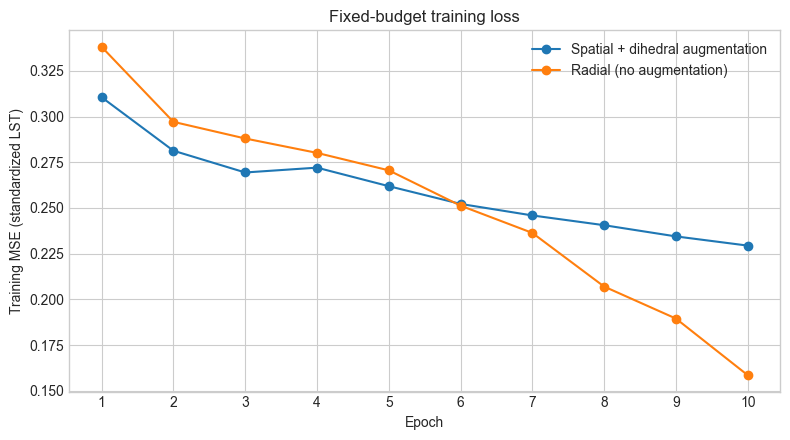

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([row['epoch'] for row in spatial_result.history],
        [row['train_mse_standardized'] for row in spatial_result.history],
        marker='o', label='Spatial + dihedral augmentation')
ax.plot([row['epoch'] for row in radial_result.history],
        [row['train_mse_standardized'] for row in radial_result.history],
        marker='o', label='Radial (no augmentation)')
ax.set(xlabel='Epoch', ylabel='Training MSE (standardized LST)', xticks=range(1, config.epochs + 1))
ax.set_title('Fixed-budget training loss')
ax.legend()
plt.tight_layout()
plt.show()

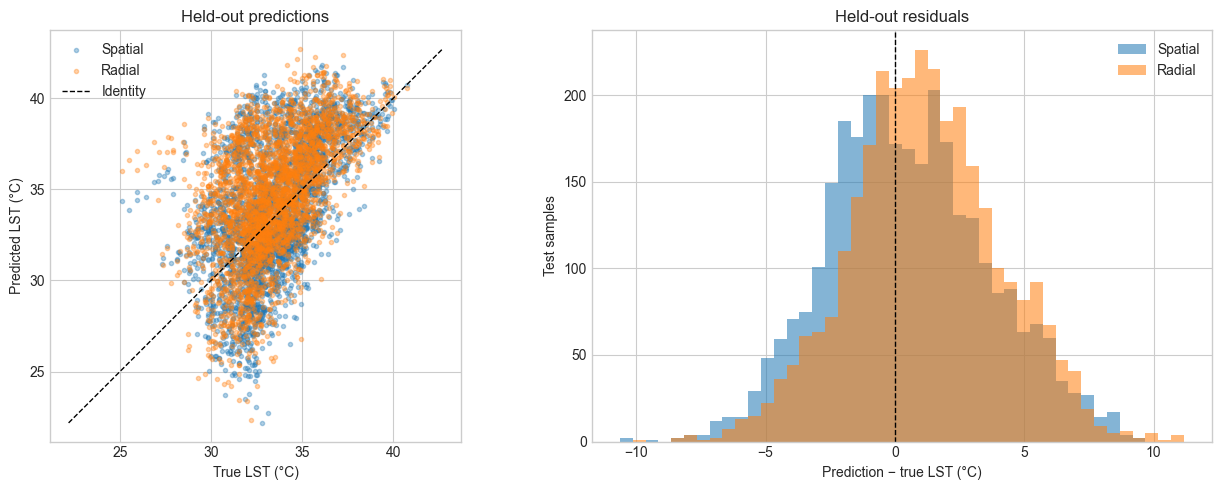

In [7]:
targets = spatial_result.targets_c
plot_min = float(min(targets.min(), spatial_result.predictions_c.min(), radial_result.predictions_c.min()))
plot_max = float(max(targets.max(), spatial_result.predictions_c.max(), radial_result.predictions_c.max()))
spatial_residuals = spatial_result.predictions_c - targets
radial_residuals = radial_result.predictions_c - targets

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(targets, spatial_result.predictions_c, s=9, alpha=0.35, label='Spatial')
axes[0].scatter(targets, radial_result.predictions_c, s=9, alpha=0.35, label='Radial')
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'k--', linewidth=1, label='Identity')
axes[0].set(xlabel='True LST (°C)', ylabel='Predicted LST (°C)', title='Held-out predictions')
axes[0].set_aspect('equal', adjustable='box')
axes[0].legend()

bins = np.linspace(min(spatial_residuals.min(), radial_residuals.min()),
                   max(spatial_residuals.max(), radial_residuals.max()), 45)
axes[1].hist(spatial_residuals, bins=bins, alpha=0.55, label='Spatial')
axes[1].hist(radial_residuals, bins=bins, alpha=0.55, label='Radial')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set(xlabel='Prediction − true LST (°C)', ylabel='Test samples', title='Held-out residuals')
axes[1].legend()
plt.tight_layout()
plt.show()

## Six fixed test examples

Red, green, and blue represent sealed soil, high green, and water. The circle marks the 100 m support and the white square is the 30 m Landsat footprint; both are display overlays only.

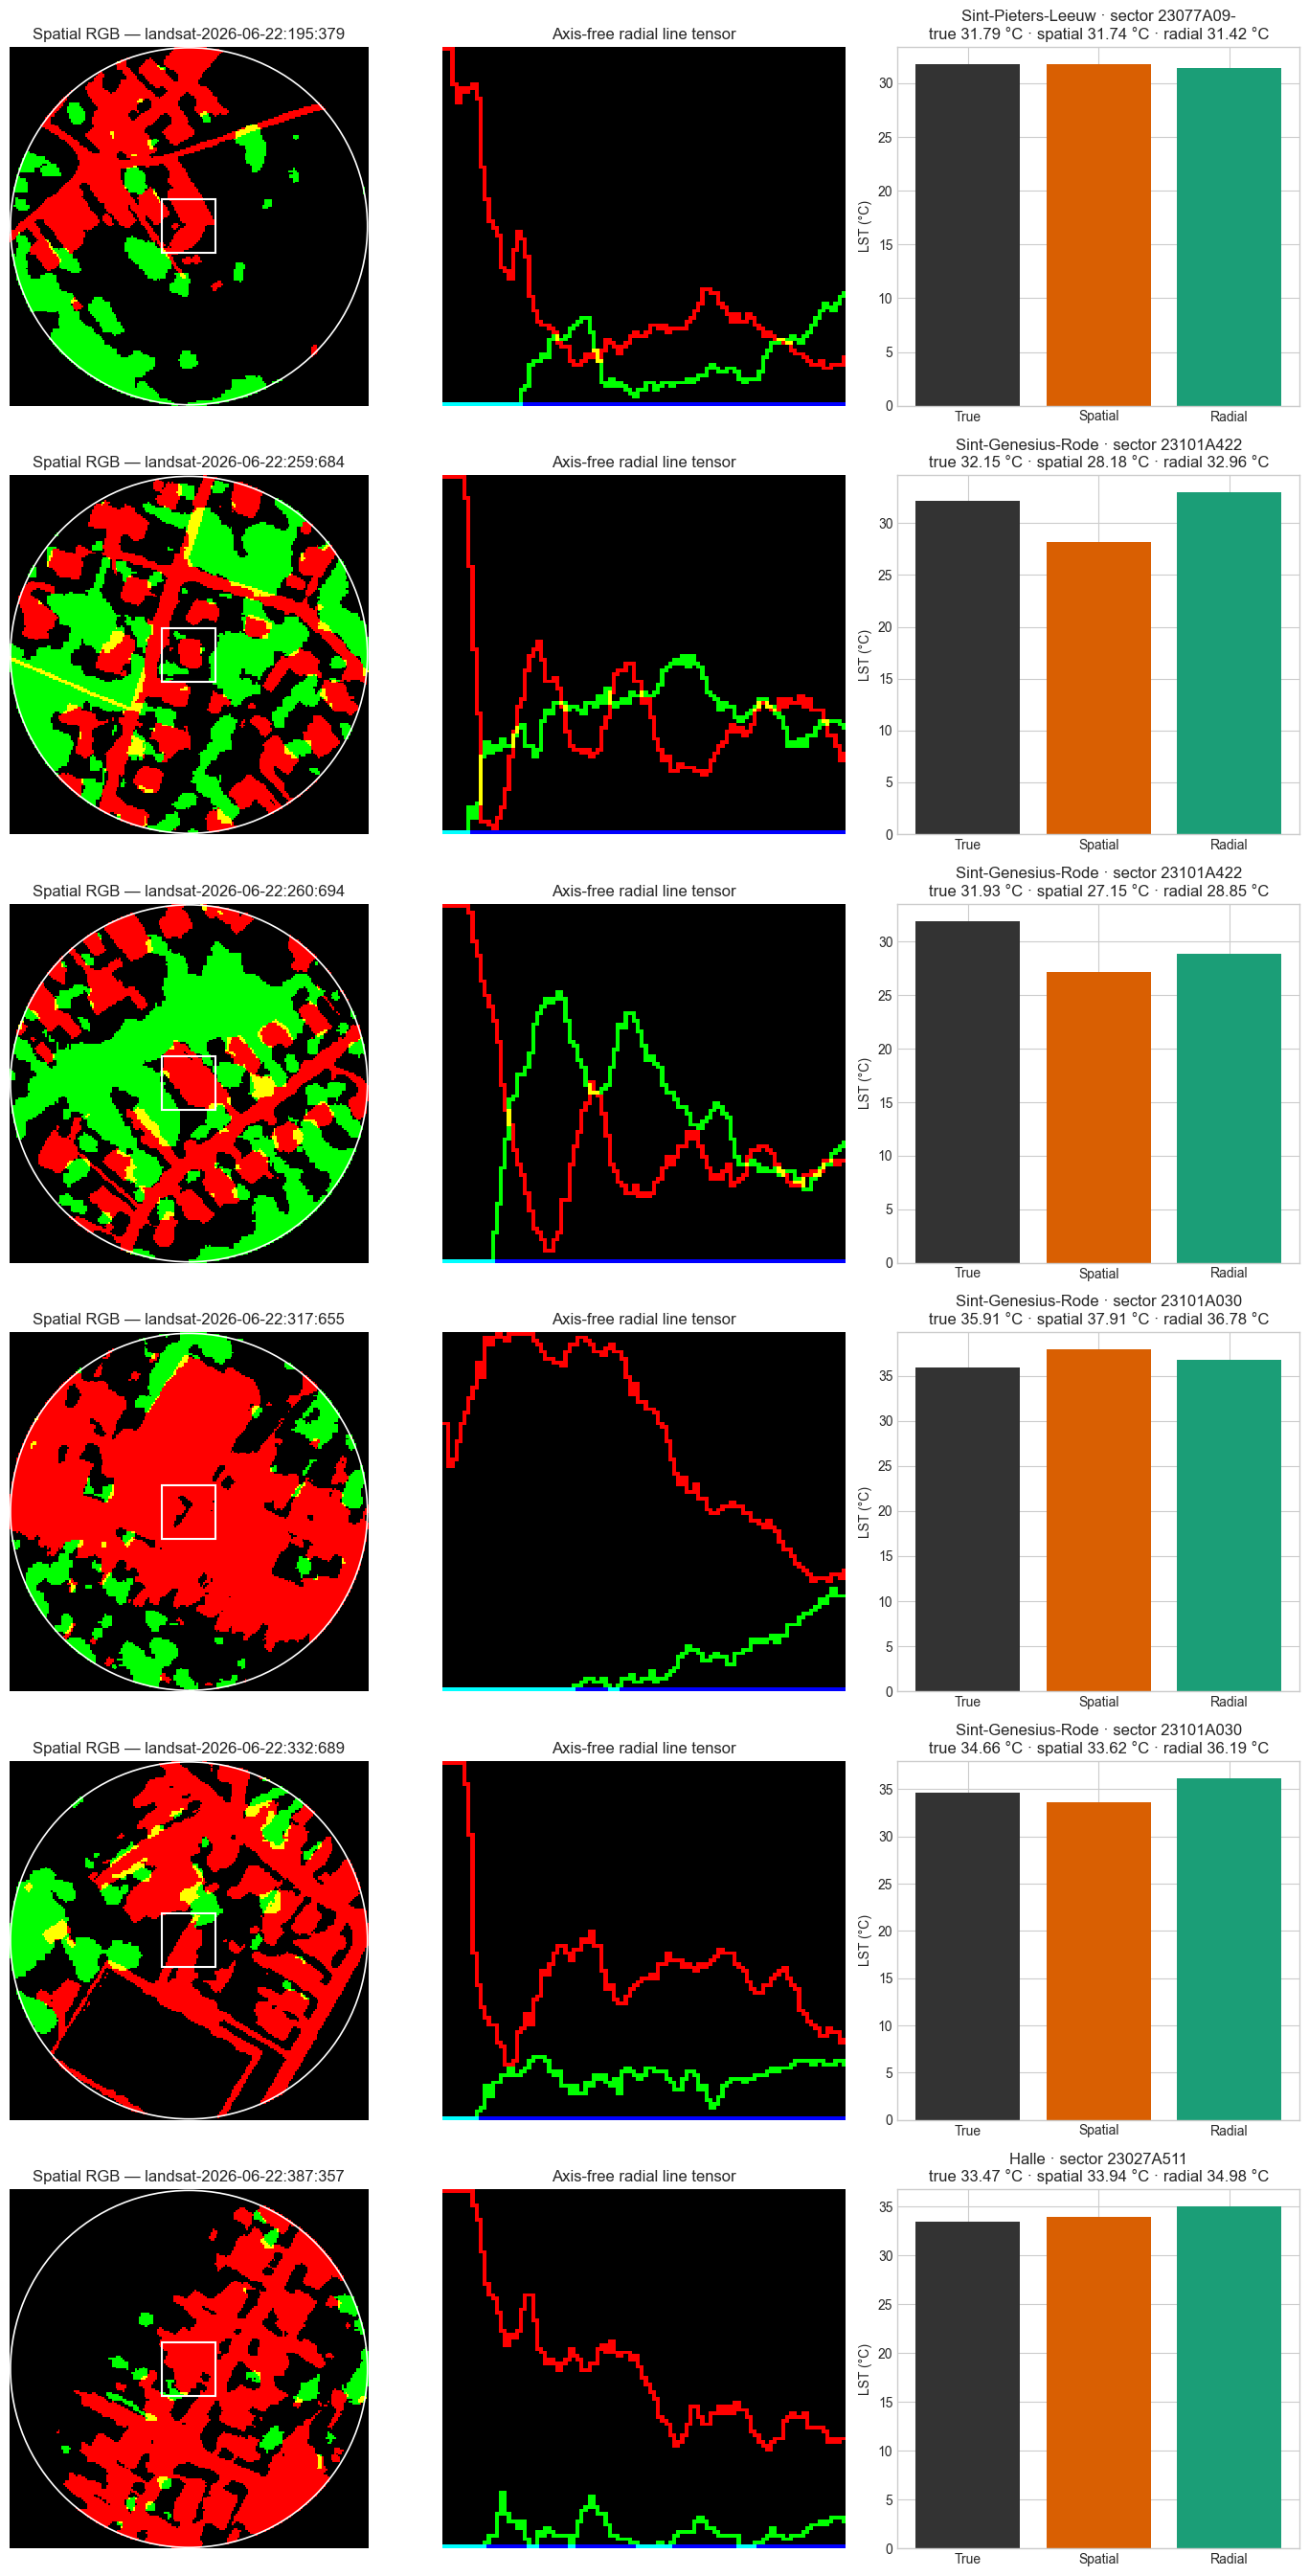

In [8]:
rng = np.random.default_rng(42)
example_positions = np.sort(rng.choice(len(fold.test_indices), size=6, replace=False))
example_catalog_indices = fold.test_indices[example_positions]
spatial_examples = ImageRegressionDataset(catalog, 'spatial', indices=example_catalog_indices)
radial_examples = ImageRegressionDataset(catalog, 'radial', indices=example_catalog_indices)

fig, axes = plt.subplots(6, 3, figsize=(14, 27))
try:
    for row_number, test_position in enumerate(example_positions):
        spatial_sample = spatial_examples[row_number]
        radial_sample = radial_examples[row_number]
        spatial_rgb = np.moveaxis(spatial_sample['input'], 0, -1)
        radial_rgb = np.moveaxis(radial_sample['input'], 0, -1)
        true_c = float(targets[test_position])
        spatial_c = float(spatial_result.predictions_c[test_position])
        radial_c = float(radial_result.predictions_c[test_position])
        metadata = spatial_sample['metadata']

        axes[row_number, 0].imshow(spatial_rgb, origin='upper', interpolation='nearest')
        axes[row_number, 0].add_patch(Circle((99.5, 99.5), 99.5, fill=False, color='white', linewidth=1.2))
        axes[row_number, 0].add_patch(Rectangle((84.5, 84.5), 30, 30, fill=False, color='white', linewidth=1.5))
        axes[row_number, 0].set_title(f"Spatial RGB — {spatial_sample['sample_id']}")
        axes[row_number, 0].axis('off')

        axes[row_number, 1].imshow(radial_rgb, origin='upper', interpolation='nearest', aspect='auto')
        axes[row_number, 1].set_title('Axis-free radial line tensor')
        axes[row_number, 1].axis('off')

        axes[row_number, 2].bar(
            ['True', 'Spatial', 'Radial'], [true_c, spatial_c, radial_c],
            color=['#333333', '#d95f02', '#1b9e77'],
        )
        axes[row_number, 2].set_ylabel('LST (°C)')
        axes[row_number, 2].set_title(
            f"{metadata['municipality']} · sector {metadata['sector_id']}\n"
            f"true {true_c:.2f} °C · spatial {spatial_c:.2f} °C · radial {radial_c:.2f} °C"
        )
finally:
    spatial_examples.close()
    radial_examples.close()

plt.tight_layout()
plt.show()

In [9]:
print(
    f"Completed {config.epochs} spatial and {config.epochs} radial epochs on {device}; "
    f"evaluated the same {len(fold.test_indices):,} held-out samples once per model."
)

Completed 10 spatial and 10 radial epochs on cuda; evaluated the same 3,078 held-out samples once per model.
